In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adam

### 1. 讀入 CIFAR-10 數據集

CIFAR-10 是一個小尺吋（32x32）彩色圖片資料集，其中，訓練集包含了 50000 張大小為 32x32 的彩色圖片；測試集包含了 10000 張大小為 32x32 的彩色圖片。CIFAR-10 的圖片資料可分為以下 10 個種類：
* 飛機 (airplan)
* 交通工具 (automobile)
* 鳥 (bird)
* 貓 (cat)
* 鹿 (deer)
* 狗 (dog)
* 青蛙 (frog)
* 馬 (horse)
* 船 (ship)
* 卡車 (truck)



In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


### 2. 資料整理

#### 資料尺寸與通道數（Channel）

由於 CNN 模型的輸入資料必須是圖片，所以我們需要注意一張圖有多少個 channel。

因為CIFAR-10資料集的資料為彩色圖片，每一個像素點，其實包含了紅色（Red）、綠色（Green）以及藍色（Blue）三原色的強度，所以每一張圖有三個 channel，以及代表三種顏色的強度。

In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
print(f"資料的最小值: {np.min(x_train)}")
print(f"資料的最大值: {np.max(x_train)}")

資料的最小值: 0
資料的最大值: 255


In [ ]:
x_train = x_train/255
x_test = x_test/255

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
y_train.shape

(50000, 10)

### 3. step 1: 打造函數學習機 (CNN)

In [ ]:
model = Sequential([

Conv2D(16, (3, 3), padding='same', input_shape=(32, 32, 3), activation='relu'),
MaxPool2D(),
Conv2D(32, (3, 3), padding='same', activation='relu'),
MaxPool2D(),
Conv2D(64, (3, 3), padding='same', activation='relu'),
MaxPool2D(),
Flatten(),
Dense(10, activation='softmax')

          ])

# 16*5*5*3 + 16
# 32*5*5*16 + 32
# 64*5*5*32 + 64


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 16, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │          10,250 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,834 (132.16 KB)

 Trainable params: 33,834 (132.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='mse',optimizer=Adam(learning_rate=0.001),metrics=['accuracy'])

### 4. step 2: fit

In [ ]:
model.fit(x_train, y_train, batch_size=100, epochs=20)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3206 - loss: 0.0789
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5253 - loss: 0.0617
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5883 - loss: 0.0550
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6304 - loss: 0.0501
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6590 - loss: 0.0465
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6816 - loss: 0.0436
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7002 - loss: 0.0415
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7168 - loss: 0.0397
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7267 - loss: 0.0383
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7448 - loss: 0.0361
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7524 - loss: 0.0350
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

準備標籤資料的中英文對照

In [ ]:
from ipywidgets import interact_manual

In [ ]:
class_name = ['飛機', '汽車', '鳥', '貓', '鹿', '狗', '青蛙', '馬', '船', '卡車']

In [ ]:
def test(測試編號):
    plt.imshow(x_test[測試編號], cmap='Greys')
    print('神經網路判斷為:', class_name[y_predict[測試編號]])

In [ ]:
interact_manual(test, 測試編號=(0, 9999));

In [ ]:
score = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7081 - loss: 0.0412


In [ ]:
print(f"loss: {score[0]}")
print(f" 正確率 : {score[1]*100:.2f}%")

loss: 0.04143377020955086
 正確率 : 70.99%


Saving images (1).jpg to images (1) (1).jpg


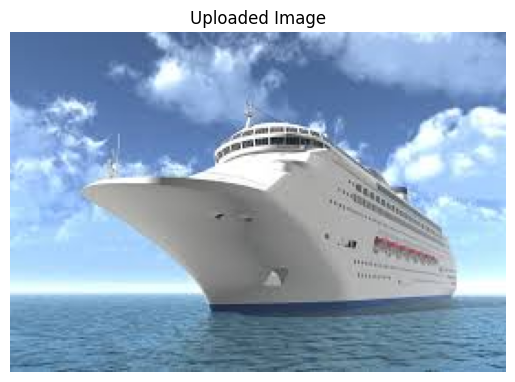

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Probability of airplane: 0.04
Probability of car: 0.00
Probability of bird: 0.02
Probability of cat: 0.07
Probability of deer: 0.02
Probability of dog: 0.01
Probability of frog: 0.00
Probability of hourse: 0.00
Probability of ship: 0.83
Probability of truck: 0.00


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image
import io
from google.colab import files
import matplotlib.pyplot as plt

def preprocess_image(image):
    """將上傳的圖片轉換為模型需要的格式"""
    # 調整大小為32x32
    image = image.resize((32, 32), Image.Resampling.BILINEAR)
    # 轉換為numpy數組
    image_array = np.array(image)
    # Check if the image has 3 color channels (RGB)
    if image_array.ndim == 3:
        # No changes needed if it's a color image
        pass # Keep the 3 color channels
    else:
        # If grayscale, stack it 3 times to simulate color channels
        image_array = np.stack([image_array] * 3, axis=-1) # Simulate 3 color channels if grayscale
    # 將數據標準化到0-1範圍
    image_array = image_array / 255.0
    # 重塑為模型輸入的形狀 (adjusting to match expected shape)
    image_array = image_array.reshape(1, 32, 32, 3) # Reshape to include dimensions and three color channels
    return image_array

def predict(image):
    """使用模型進行預測"""
    # 預處理圖片
    image_array = preprocess_image(image)
    # 使用模型進行預測
    predictions = model.predict(image_array)
    # 返回每個類別的機率
    return predictions[0]

# 上傳圖片
uploaded = files.upload()

# 讀取上傳的圖片
for filename in uploaded.keys():
    # 打開圖片
    image = Image.open(io.BytesIO(uploaded[filename]))
    # 顯示圖片
    plt.imshow(image, cmap='gray')
    plt.title('Uploaded Image')
    plt.axis('off')
    plt.show()
    # 進行預測
    probabilities = predict(image)
    # 定義類別名稱
    class_names = ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'hourse', 'ship', 'truck']
    # 顯示預測結果
    for i, prob in enumerate(probabilities):
        print(f'Probability of {class_names[i]}: {prob:.2f}')